In [3]:
import concurrent.futures
import numpy as np
import pandas as pd
from functools import partial
import time

In [4]:
df = pd.DataFrame(np.random.binomial(n=1000, p=0.2, size=(10000,2)))

# a no op function that simulates a transformation that takes some time to complete
def do_work(row, duration):
    time.sleep(duration)
    return True

FUNCTION_RUN_TIME = 0.0001

# simple use of apply to execute the function against the pd dataframe
def serial_calc(df, duration):
    apply_partial = partial(do_work, duration=duration)
    df['result'] = df.apply(apply_partial, axis=1)
    return df

%timeit serial_calc(df, FUNCTION_RUN_TIME)

# simple wrapper code around serial_calc to parallelize the work
def parallel_calc(df, func, n_core, duration):
    futs = []
    df_split = np.array_split(df, n_core)
#     pool = concurrent.futures.ThreadPoolExecutor(max_workers = n_core)
    pool = concurrent.futures.ProcessPoolExecutor(max_workers = n_core)
    apply_partial = partial(func, duration=duration)
    return pd.concat(pool.map(apply_partial, df_split))

%timeit parallel_calc(df, serial_calc, 32, FUNCTION_RUN_TIME)

1.42 s ± 9.58 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
184 ms ± 776 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


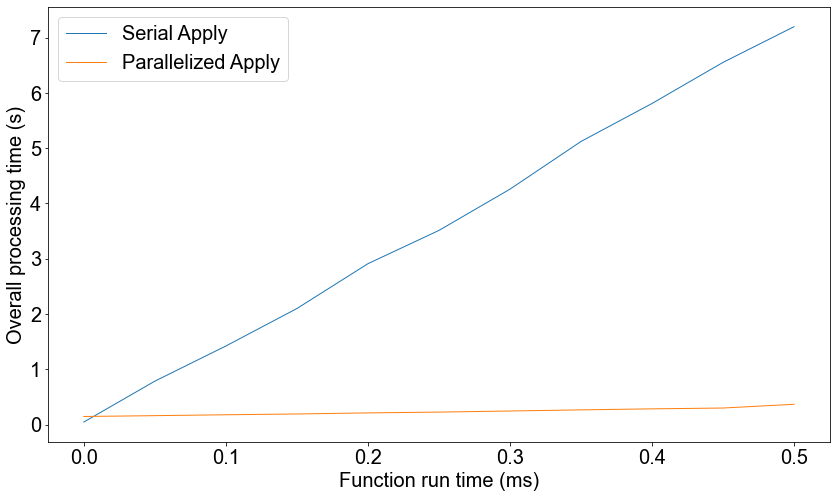

In [7]:
function_time = []
non_parallel_time = []
parallel_time = []

for d in range(11):
#     print(d)
    d_ms = d/20000
    function_time.append(d_ms)
    start = time.time()
    serial_calc(df, d_ms)
    end = time.time()
    non_parallel_time.append(end-start)
    
    start = time.time()
    parallel_calc(df, serial_calc, 32, d_ms)
    end = time.time()
    parallel_time.append(end-start)
    
import matplotlib.pyplot as plt

font = {'family' : 'Arial',
        'weight': 'normal',
        'size'   : 20}

plt.rc('font', **font)

fig, ax = plt.subplots(figsize=(14,8))
plt.xlabel('Function run time (ms)')
plt.ylabel('Overall processing time (s)')

x = [t*1000 for t in function_time]

ax.plot(x, non_parallel_time, '-', linewidth=1)
ax.plot(x, parallel_time, '-', linewidth=1)
ax.legend(['Serial Apply', 'Parallelized Apply'])

plt.show()